<a href="https://colab.research.google.com/github/lilianabs/learning-pytorch/blob/main/text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
#!pip install -q datasets scikit-learn

In [126]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

## Load dataset

In [127]:
training_corpus = fetch_20newsgroups(subset='train')
train_data, train_labels = training_corpus.data, training_corpus.target

In [128]:
test_corpus = fetch_20newsgroups(subset='test')
test_data, test_labels = test_corpus.data, test_corpus.target

In [129]:
vectorizer = TfidfVectorizer(max_features=10_000, stop_words="english")

X_train = vectorizer.fit_transform(train_data)
X_test = vectorizer.transform(test_data)

print(X_train.shape, type(X_train))

(11314, 10000) <class 'scipy.sparse._csr.csr_matrix'>


In [130]:
print(f"Number of classes: {len(np.unique(train_labels))}")

Number of classes: 20


In [131]:
class TfidfDataset(Dataset):
  def __init__(self, X, labels):
    self.X = torch.tensor(X.toarray(), dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    return self.X[idx], self.labels[idx]


In [132]:
full_train = TfidfDataset(X_train, train_labels)

val_size = int(0.1 * len(full_train))
train_ds, val_ds = random_split(full_train, [len(full_train) - val_size, val_size],
                                generator=torch.Generator().manual_seed(42))
test_ds = TfidfDataset(X_test, test_labels)

In [133]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256)
test_loader = DataLoader(test_ds, batch_size=256)

xb, yb = next(iter(train_loader))
print(xb.shape, xb.dtype, yb.shape, yb.dtype)

torch.Size([64, 10000]) torch.float32 torch.Size([64]) torch.int64


## Model (NN)

In [134]:
class TextClassificationNN(nn.Module):
  def __init__(self, in_features, n_classes):
    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Linear(128, n_classes)
    )

  def forward(self, x):
    return self.net(x)

In [135]:
in_features = X_train.shape[1]
n_classes = len(np.unique(train_labels))

In [136]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TextClassificationNN(in_features=in_features, n_classes=n_classes)
print(model)

TextClassificationNN(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=20, bias=True)
  )
)


In [137]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Train model

In [138]:
model.to(device)

TextClassificationNN(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=20, bias=True)
  )
)

In [139]:
def train_one_epoch(model, train_loader, loss_fn, optimizer):
  model.train()
  total_loss, correct, n = 0.0, 0, 0

  for X_batch, y_batch in train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    optimizer.zero_grad()
    logits = model(X_batch)

    loss = loss_fn(logits, y_batch)
    loss.backward()
    optimizer.step()

    total_loss += loss.item() * len(y_batch)
    correct += (logits.argmax(dim=1) == y_batch).sum().item()
    n += len(y_batch)

  return total_loss / n, correct / n

In [140]:
@torch.no_grad()
def evaluate(model, loader, loss_fn):
  model.eval()
  val_loss = 0.0
  correct = 0

  for X_batch, y_batch in loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    logits = model(X_batch)
    val_loss += loss_fn(logits, y_batch).item() * X_batch.size(0)
    correct += (logits.argmax(1) == y_batch).sum().item()

  val_loss /= len(loader.dataset)
  val_acc = correct / len(loader.dataset)

  return val_loss, val_acc

You need a fresh model and a fresh optimizer for every run. If you reuse the old model, the new experiment continues from weights that were already trained, and the comparison is meaningless.

In [146]:
def test_run_experiment(n_epochs=20):
  torch.manual_seed(42)
  model = TextClassificationNN(in_features, n_classes).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

  history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

  for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d} | train_loss={train_loss:.4f} | train_acc={train_acc:.3f} | val_loss={val_loss:.4f} | val_acc={val_acc:.3f}")

  return model, history

In [147]:
n_epochs = 20
model, history = test_run_experiment(n_epochs)

Epoch  1 | train_loss=2.3749 | train_acc=0.650 | val_loss=1.3849 | val_acc=0.862
Epoch  2 | train_loss=0.7966 | train_acc=0.914 | val_loss=0.5929 | val_acc=0.902
Epoch  3 | train_loss=0.3265 | train_acc=0.960 | val_loss=0.4119 | val_acc=0.920
Epoch  4 | train_loss=0.1727 | train_acc=0.981 | val_loss=0.3422 | val_acc=0.914
Epoch  5 | train_loss=0.1002 | train_acc=0.990 | val_loss=0.3109 | val_acc=0.918
Epoch  6 | train_loss=0.0621 | train_acc=0.995 | val_loss=0.2888 | val_acc=0.918
Epoch  7 | train_loss=0.0409 | train_acc=0.997 | val_loss=0.2758 | val_acc=0.920
Epoch  8 | train_loss=0.0287 | train_acc=0.999 | val_loss=0.2695 | val_acc=0.923
Epoch  9 | train_loss=0.0211 | train_acc=0.999 | val_loss=0.2645 | val_acc=0.924
Epoch 10 | train_loss=0.0164 | train_acc=0.999 | val_loss=0.2608 | val_acc=0.927
Epoch 11 | train_loss=0.0132 | train_acc=0.999 | val_loss=0.2600 | val_acc=0.924
Epoch 12 | train_loss=0.0109 | train_acc=0.999 | val_loss=0.2595 | val_acc=0.927
Epoch 13 | train_loss=0.0092

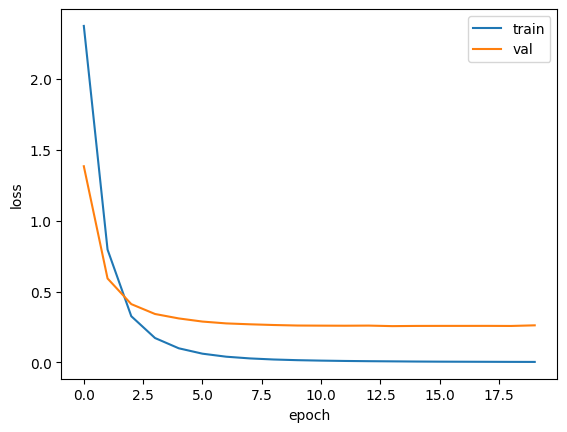

In [148]:
import matplotlib.pyplot as plt
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

## Add dropout to model

In [149]:
class TextClassificationNN(nn.Module):
  def __init__(self, in_features, n_classes, dropout):
    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(p=dropout),
        nn.Linear(128, n_classes)
    )

  def forward(self, x):
    return self.net(x)

In [150]:
def run_experiment(dropout=0.0, weight_decay=0.0, n_epochs=20):
  torch.manual_seed(42)
  model = TextClassificationNN(in_features, n_classes, dropout=dropout).to(device)
  optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=weight_decay)

  history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

  for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d} | train_loss={train_loss:.4f} | train_acc={train_acc:.3f} | val_loss={val_loss:.4f} | val_acc={val_acc:.3f}")

  return model, history